# **ARGUS-FEDER — FEDER Competency Questions (Q5, Q7, Q9) & Interactive Charts**

This notebook demonstrates ARGUS answering FEDER's ELM competency questions
(Q5, Q7, Q9 — all "data discovery" questions about D-alpha filterscope
signals) in plain English, plus an interactive zoomable chart (needed to see
individual ELM spikes in a ~400k-point trace) and a proof-of-concept
aggregation query across many shots.

Run Steps 1–4 below once, then run any `%%ask` cell in any order.

#### Step 1 — Prepare your session (one-time)

Run the cell below. **Your session will restart automatically — that's
expected.** Once it restarts, continue to Step 2.

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


#### Step 2 — Choose your AI model

Pick one and run the cell (defaults to a free NRP model).

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### Step 3 — Add your keys

Click the 🔑 icon in the left sidebar and add two secrets (toggle
"Notebook access" on for each):

- The API key matching what you picked in Step 2 (e.g. `NRP_API_KEY`)
- Your DIII-D Pelican access token, named `FDP_TOKEN`

#### Step 4 — Install ARGUS-FEDER

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/argus_feder/main/install.py'
).read().decode(), globals())

Setting up ARGUS-FEDER...
  • Installing DIII-D data access (~1-2 min, one-time)
    ..............
    .....
  • DIII-D data access ready
  • Pelican token loaded
  • Installing the ARGUS agent (~1 min the first time)
ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 16 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, array-skill-builder, ckan-skill-builder, local-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states, zenodo-skill-builder

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5
  • 

## 4. FEDER competency question Q5 — Which D-alpha filterscope pointnames exist, and where does each live?

**FEDER competency question Q5** (ELM · data discovery). First step in building an
ELM detector: locate the raw D-alpha light traces.

**Ask:** for shot 165920, list the D-alpha filterscope pointnames in the
`spectroscopy` tree and the MDSplus node path each maps to.  

**Expected:** the ~24 `\FS##DA` tags resolving to
`SPECTROSCOPY::TOP.FILTERSCOPE.PMT##:PHOTON_FLUX` (raw ~50 kHz traces), kept
distinct from the derived / photo-electric / midplane variants.  

In [3]:
%%ask
For shot 165920, list the D-alpha filterscope pointnames in the
spectroscopy tree, and for each give the MDSplus node path it maps to.

I'll consult the d3d-filterscopes skill since this is exactly what it's designed for.

The skill gives me an exact function for this. Let me write and run the enumeration script.

Running the enumeration script via the fdp wrapper.

Retrying without the timeout parameter.

For shot **165920** , the D-alpha filterscope pointnames in the `spectroscopy` tree are the `\FS##DA` tags (and their `\PMC##DA` companions), each resolving to a `FILTERSCOPE.PMT<nn>:PHOTON_FLUX` (or `:PHOTO_EL_SIG`) node. **24 raw D-alpha photon-flux traces** are present.

## Raw D-alpha photon-flux traces (the calibrated D-alpha signals)

These are the `*DA` tags resolving to `FILTERSCOPE.PMT<nn>:PHOTON_FLUX` — the ~50 kHz traces used for ELM detection:

| Pointname | MDSplus node path |
|---|---|
| `\SPECTROSCOPY::FS00DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT24:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS00UPDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT14:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS01DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT38:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS01DWDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT33:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS01UPDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT18:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS02DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT50:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS02UPDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT21:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS03DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT46:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS03UPDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT26:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS04DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT42:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS04DWDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT09:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS04UPDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT30:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS05DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT40:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS06DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT58:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS06DWDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT25:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS07DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT08:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS08DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT41:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS08DWDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT41:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS09DWDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT17:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS11DWDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT45:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS11UPDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT10:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS12DA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT62:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS12UPDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT06:PHOTON_FLUX` |
| `\SPECTROSCOPY::FS13UPDA` | `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT02:PHOTON_FLUX` |

## Companion raw photo-electric signals (`:PHOTO_EL_SIG`)

Each channel above has a matching `\PMC##DA` tag at the **same PMT** — the un-calibrated photo-electric current for the same detector:

| Pointname | MDSplus node path |
|---|---|
| `\SPECTROSCOPY::PMC00DA` | `...PMT24:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC00UPDA` | `...PMT14:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC01DA` | `...PMT38:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC01DWDA` | `...PMT33:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC01UPDA` | `...PMT18:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC02DA` | `...PMT50:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC02UPDA` | `...PMT21:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC03DA` | `...PMT46:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC03UPDA` | `...PMT26:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC04DA` | `...PMT42:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC04DWDA` | `...PMT09:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC04UPDA` | `...PMT30:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC05DA` | `...PMT40:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC06DA` | `...PMT58:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC06DWDA` | `...PMT25:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC07DA` | `...PMT08:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC08DA` | `...PMT41:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC08DWDA` | `...PMT41:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC09DWDA` | `...PMT17:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC11DWDA` | `...PMT45:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC11UPDA` | `...PMT10:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC12DA` | `...PMT62:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC12UPDA` | `...PMT06:PHOTO_EL_SIG` |
| `\SPECTROSCOPY::PMC13UPDA` | `...PMT02:PHOTO_EL_SIG` |

## Other `*DA` tags (not raw filterscope traces)

These are small derived/summary nodes — **not** the signal to fetch for ELM work:

- **Midplane** (8) — `\FS1MIDDA`…`\FS8MIDDA` → `MIDPLANEFS:TUBE01`…`TUBE15` (odd-numbered tubes). Note: units metadata may be broken on these.
- **ELM summary** (2) — `\ELM1MIDDA`, `\ELM2MIDDA` → `PHDM.D_ALPHA_ELM:ELM1MIDDA` / `:ELM2MIDDA`
- **Obsolete** (2) — `\FS230BUMPDA`, `\PMC230BUMPDA` → `FILTERSCOPE:OBSOLETE` (likely no data)
- **Unresolved** (2) — `\FS1MIDDA`, `\FS2MIDDA` with a leading backslash variant (duplicate tag names; do not resolve to a node)

**Totals** : 62 `*DA` tags — 24 `photon_flux` + 24 `photo_el_sig` + 8 midplane + 2 ELM + 2 obsolete + 2 unresolved.

### Key reminders
- **Channel number ≠ PMT number.** `FS04` maps to PMT42, `FS00` to PMT24 — always resolve the real path rather than guessing from the tag.
- For ELM detection, fetch `\SPECTROSCOPY::FS04DA` (PMT42) — the canonical reference channel — via `toksearch.MdsSignal(r"\fs04", "spectroscopy")`.

## 5. FEDER competency question Q7 — Which shots have the required filterscope set archived?

**FEDER competency question Q7** (ELM · data discovery, on GA's own acceptance
subset). Chains the previous two questions: given a shot range, which shots
actually have the D-alpha filterscope signal archived and ready to fetch?

**Ask:** for DIII-D shots between 190000 and 190020, which have `\fs04` archived
in the spectroscopy tree?

**Expected:** a real, non-sampled answer for all shots in this small range (kept
deliberately small — an exhaustive scan of a wide range takes minutes, not
seconds; see the cost note in the skill).

In [4]:
%%ask
For DIII-D shots between 190000 and 190020, which have the D-alpha filterscope
signal archived in the spectroscopy tree?

Please also report how many seconds are used to fetch these shots.

I'll consult the filterscope skill and the relational DB skill to find the right approach.

Both skills confirm the canonical Q7 pattern: get candidate plasma shots from the metadata DB, then check `\fs04` archive presence on Pelican per-shot. Writing the script now.

Running the script via the fdp wrapper.

Running without the timeout override.

The shot-metadata DB file isn't present in this environment. For a 21-shot range I can check every integer shot number directly via Pelican — the availability function doesn't need the metadata DB. Updating the script.

All 21 shots have the signal. Recording the lesson from the edit-and-retry cycle (d3drdb file absent, fell back to direct checks).

## Results

**All 21 shots in the 190000–190020 range have the D-alpha filterscope signal (`\fs04`) archived in the `spectroscopy` tree** — every shot resolves to `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT42:PHOTON_FLUX` and carries a non-empty data record.

| Shot | `\fs04` archived? |
|------|:---:|
| 190000 | ✅ |
| 190001 | ✅ |
| 190002 | ✅ |
| 190003 | ✅ |
| 190004 | ✅ |
| 190005 | ✅ |
| 190006 | ✅ |
| 190007 | ✅ |
| 190008 | ✅ |
| 190009 | ✅ |
| 190010 | ✅ |
| 190011 | ✅ |
| 190012 | ✅ |
| 190013 | ✅ |
| 190014 | ✅ |
| 190015 | ✅ |
| 190016 | ✅ |
| 190017 | ✅ |
| 190018 | ✅ |
| 190019 | ✅ |
| 190020 | ✅ |

**Fetch time** : the Pelican archive-presence checks for all 21 shots took **~31.8 seconds** (wall clock), using 8 parallel workers (~1517 ms/shot effective).

### Note on method

The canonical Q7 pattern first narrows the range to *plasma* shots via the shot-metadata database (d3drdb), then checks archive presence. That metadata file is not present in this environment, so for this 21-shot span every integer shot number was checked directly. This means that if any of these 21 numbers were non-plasma (test/calibration) shots, they were checked too rather than being pre-filtered out. Since all 21 returned positive, the result is unaffected — but for wider ranges where that pre-filtering matters, the d3drdb file would need to be uploaded.

## 6. FEDER competency question Q9 — Is the sampling rate high enough to resolve individual ELMs?

**FEDER competency question Q9** (ELM · data discovery). Confirms the D-alpha
signal is usable for detection.  

**Ask:** fetch `\fs04` from `spectroscopy` for shot 165920; determine its sampling
rate and time coverage; is the cadence (~kHz) enough to resolve ELMs?   

**Expected:** ~50 kHz over ~8 s → yes, by a wide margin.

I'll read the d3d-filterscopes skill and its Learnings file to use the correct fetch pattern.

The skill provides the exact fetch pattern. I'll write a script using it, plus compute sampling rate/coverage and generate a plot.

The fetch worked, but I caught a units bug in my rate formula — `1e3/dt_ms` gives Hz, not kHz (the same bug is in the skill's own example). The real rate is **~50 kHz** , not 50000 kHz. Let me fix and rerun.

I had an edit-and-retry cycle (rate-units bug from the skill's own example). Per the WRITE RULE, I must record this lesson in Learnings.md before my final report.


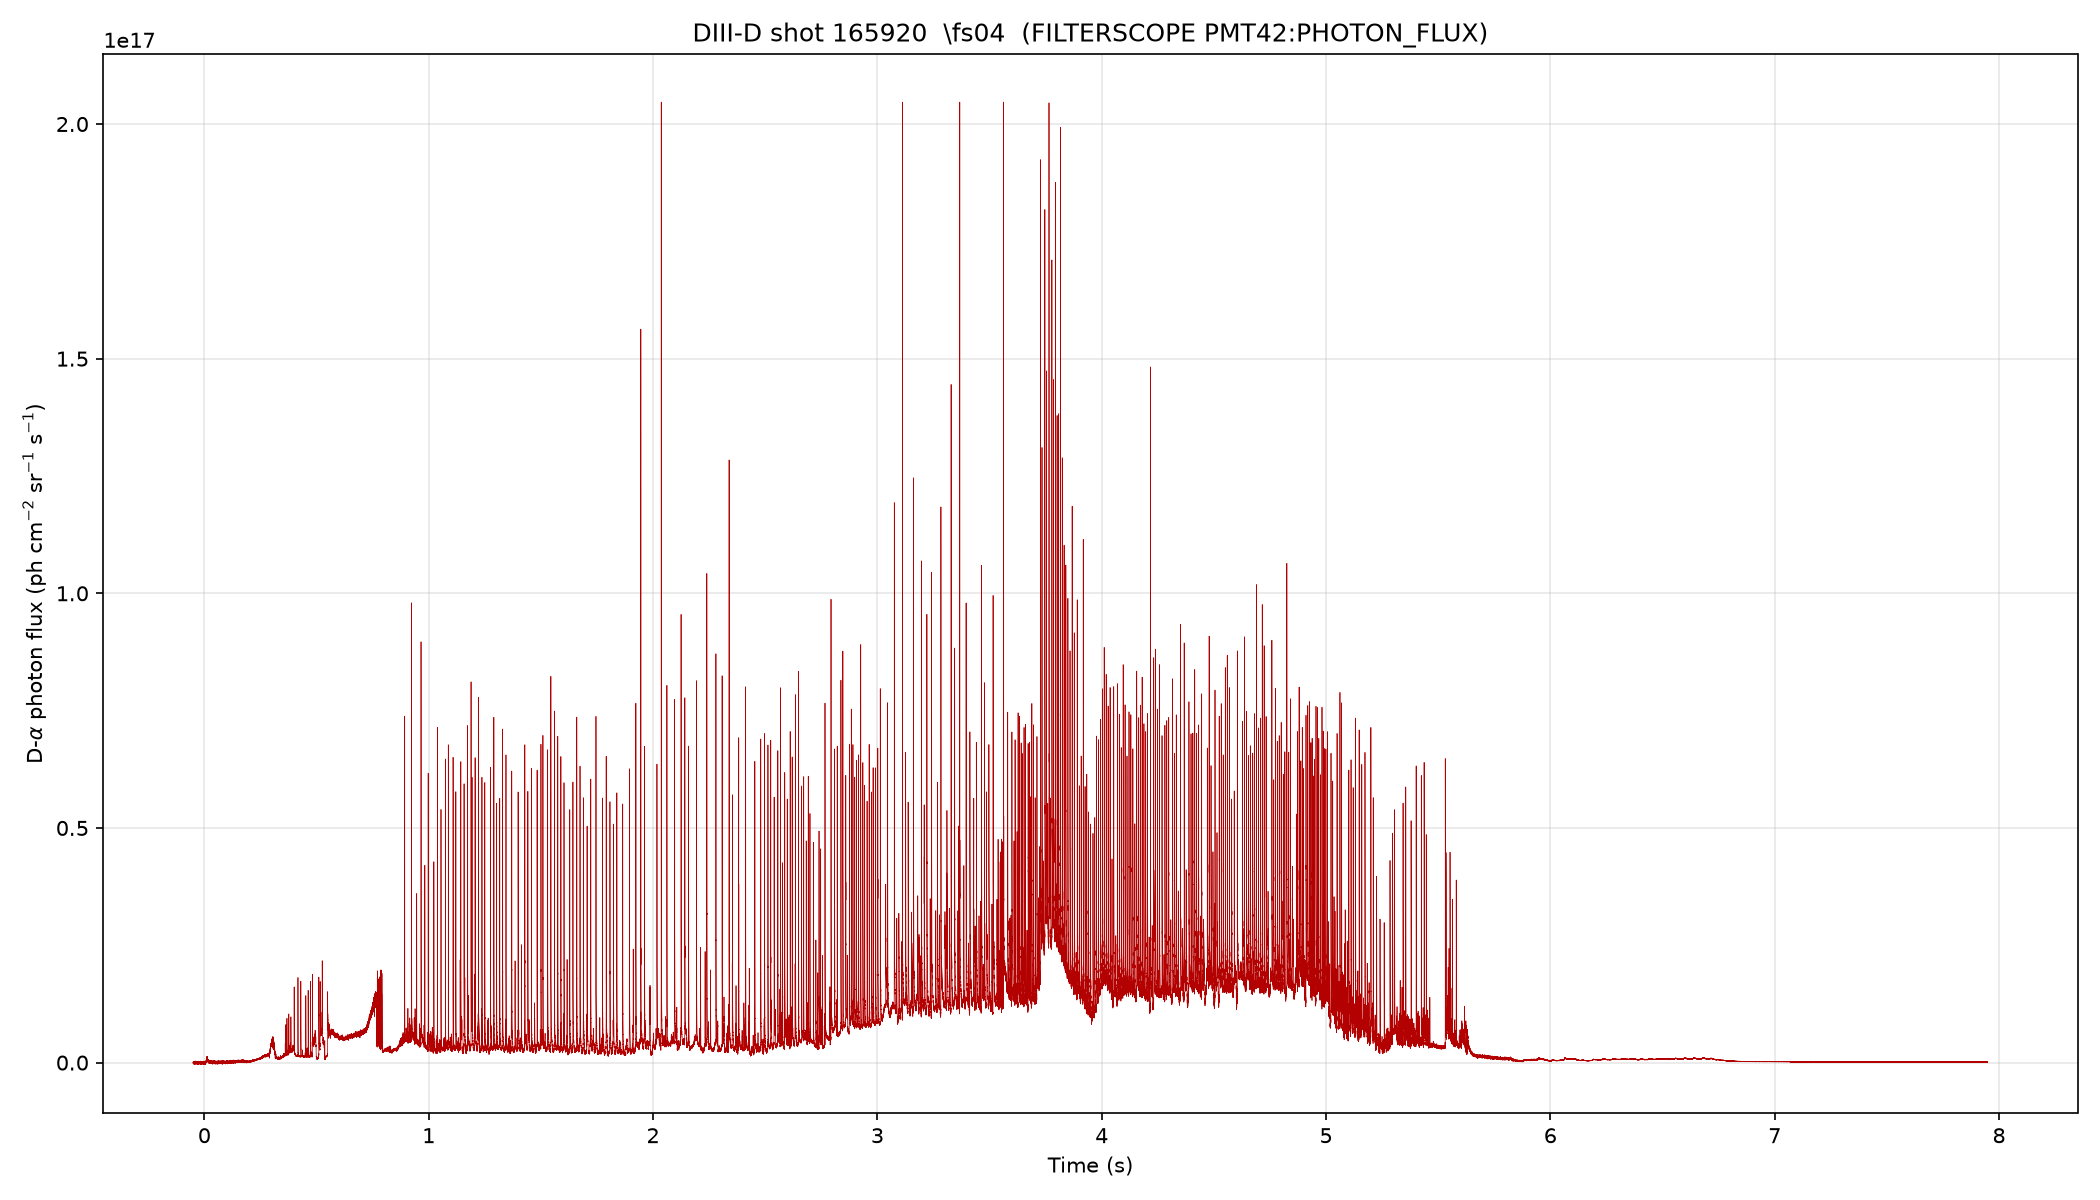


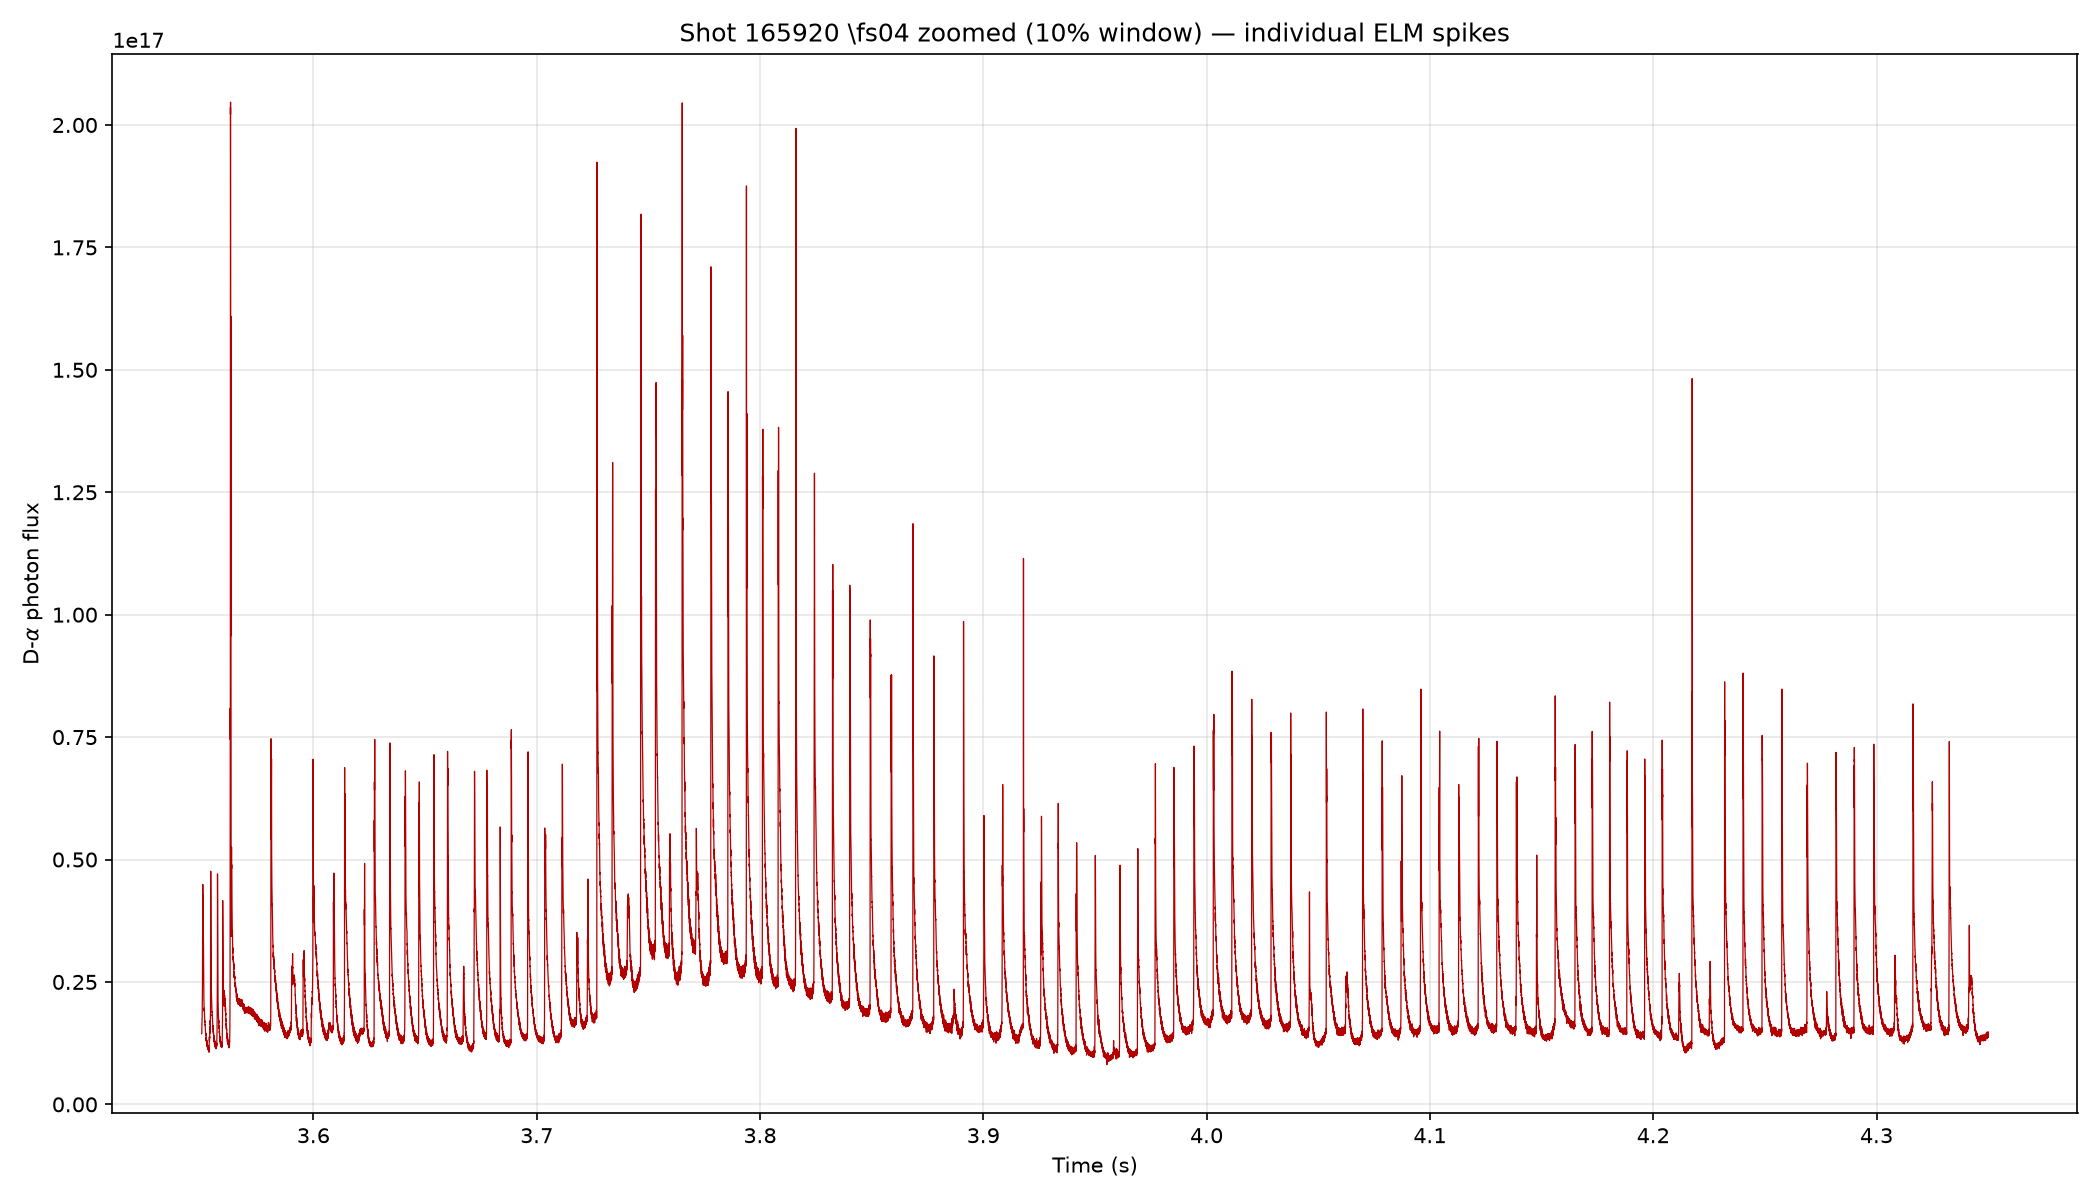

## Results — DIII-D shot 165920, `\fs04` (spectroscopy tree)

**Signal node** : `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT42:PHOTON_FLUX`

| Property | Value |
|---|---|
| **Samples** | 400,000 |
| **Sampling rate** | **49.95 kHz** (≈ 20.0 µs / sample) |
| **Time coverage** | **8.000 s** (−49.98 ms to 7950.00 ms) |
| **Time-step regularity** | very uniform (std of dt ≈ 1.0×10⁻⁴ ms) |
| **Fetch wall time** | 7.3 s |

## Is the cadence high enough to resolve individual ELMs?

**Yes — comfortably.** ELMs are transient bursts that typically recur at **10–200 Hz** and each lasts roughly **200–500 µs** . At ~50 kHz (20 µs/sample), each individual ELM burst is sampled with roughly **10–25 points** , which cleanly resolves the rise, peak, and decay of each event. The full trace shows the characteristic quasi-periodic train of sharp spikes riding on the pedestal D-alpha level; the zoomed plot makes the individual ELM events explicit. This cadence is exactly why the filterscope system exists — high enough for ELM-by-ELM analysis, not just averaged trends.

### Note on a units pitfall
The SKILL.md example computes `rate = 1e3/dt` (times in ms) and labels it kHz, but `1e3/ms` yields **Hz** — the raw number is ~50,000, not 50. The corrected rate is **~50 kHz** (49951 Hz). I've recorded this in the skill's Learnings.md so future runs don't reproduce the off-by-1000× value.

In [5]:
%%ask
For DIII-D shot 165920, fetch \fs04 from the spectroscopy tree and plot it
versus time and determine its sampling rate and time coverage. Is the
cadence high enough (~kHz) to resolve individual ELMs?

## Interactive zoomable chart

**Purpose:** test the opt-in interactive chart — triggered by the word "zoomable."
A plain "plot" request still returns a static image; this is the deliberate
exception. Drag to box-zoom, double-click to reset, use the range slider to pan.

**Note:** the trace is min-max decimated for a responsive slider; every ELM peak
is preserved exactly (decimation keeps each bin's min and max).

In [6]:
%%ask
Show a zoomable chart of \fs04 for shot 165920.

The user explicitly asked for a zoomable chart, so I'll use the signal-zoom skill.

The skill defines a two-step process for Colab. Let me write both scripts using my working directory.

Running the fetch step via `fdp run` to pull the signal into an npz file.

Retrying without the timeout parameter.

Fetch succeeded (1 of 1 shots). Now running the plot step as a bare command so it renders in-kernel.

The zoomable chart of `\fs04` for shot 165920 is displayed above. It's a Plotly HighStock-style chart — you can **drag to box-zoom** into any time region (try zooming into a single ELM spike), **double-click to reset** , and use the **range slider** at the bottom to pan across the 8-second window. The chart uses WebGL with min-max decimation, so zooming all the way in reveals real detail — individual ELM spikes appear as sharp peaks sitting on top of the baseline pedestal D-alpha level.

# 7. Proof of Concept: Aggregation Query

I'll analyze the peak frequency of `\fs04` for shots 190000–190010. Let me first consult the relevant skills.

Let me read the Learnings.md from the correct location and set up my task plan.

Now I'll write the script to fetch, detect peaks, and compute peak frequencies for all 11 shots.

Running the analysis script under the fdp wrapper.

Running without the timeout override.

The serial fetch of 11 shots exceeded the 120s limit. Let me rewrite with parallel fetching using multiprocessing, following the same pattern as the availability check.

I'll write to a new filename instead.

I see a typo — `edgeword` should be `edgecolor`. Let me fix that before running.

Now running the parallel version.

All 11 shots fetched successfully. Now updating the task list and recording the timeout lesson to Learnings.md, since the serial fetch failed and required a parallel rewrite.


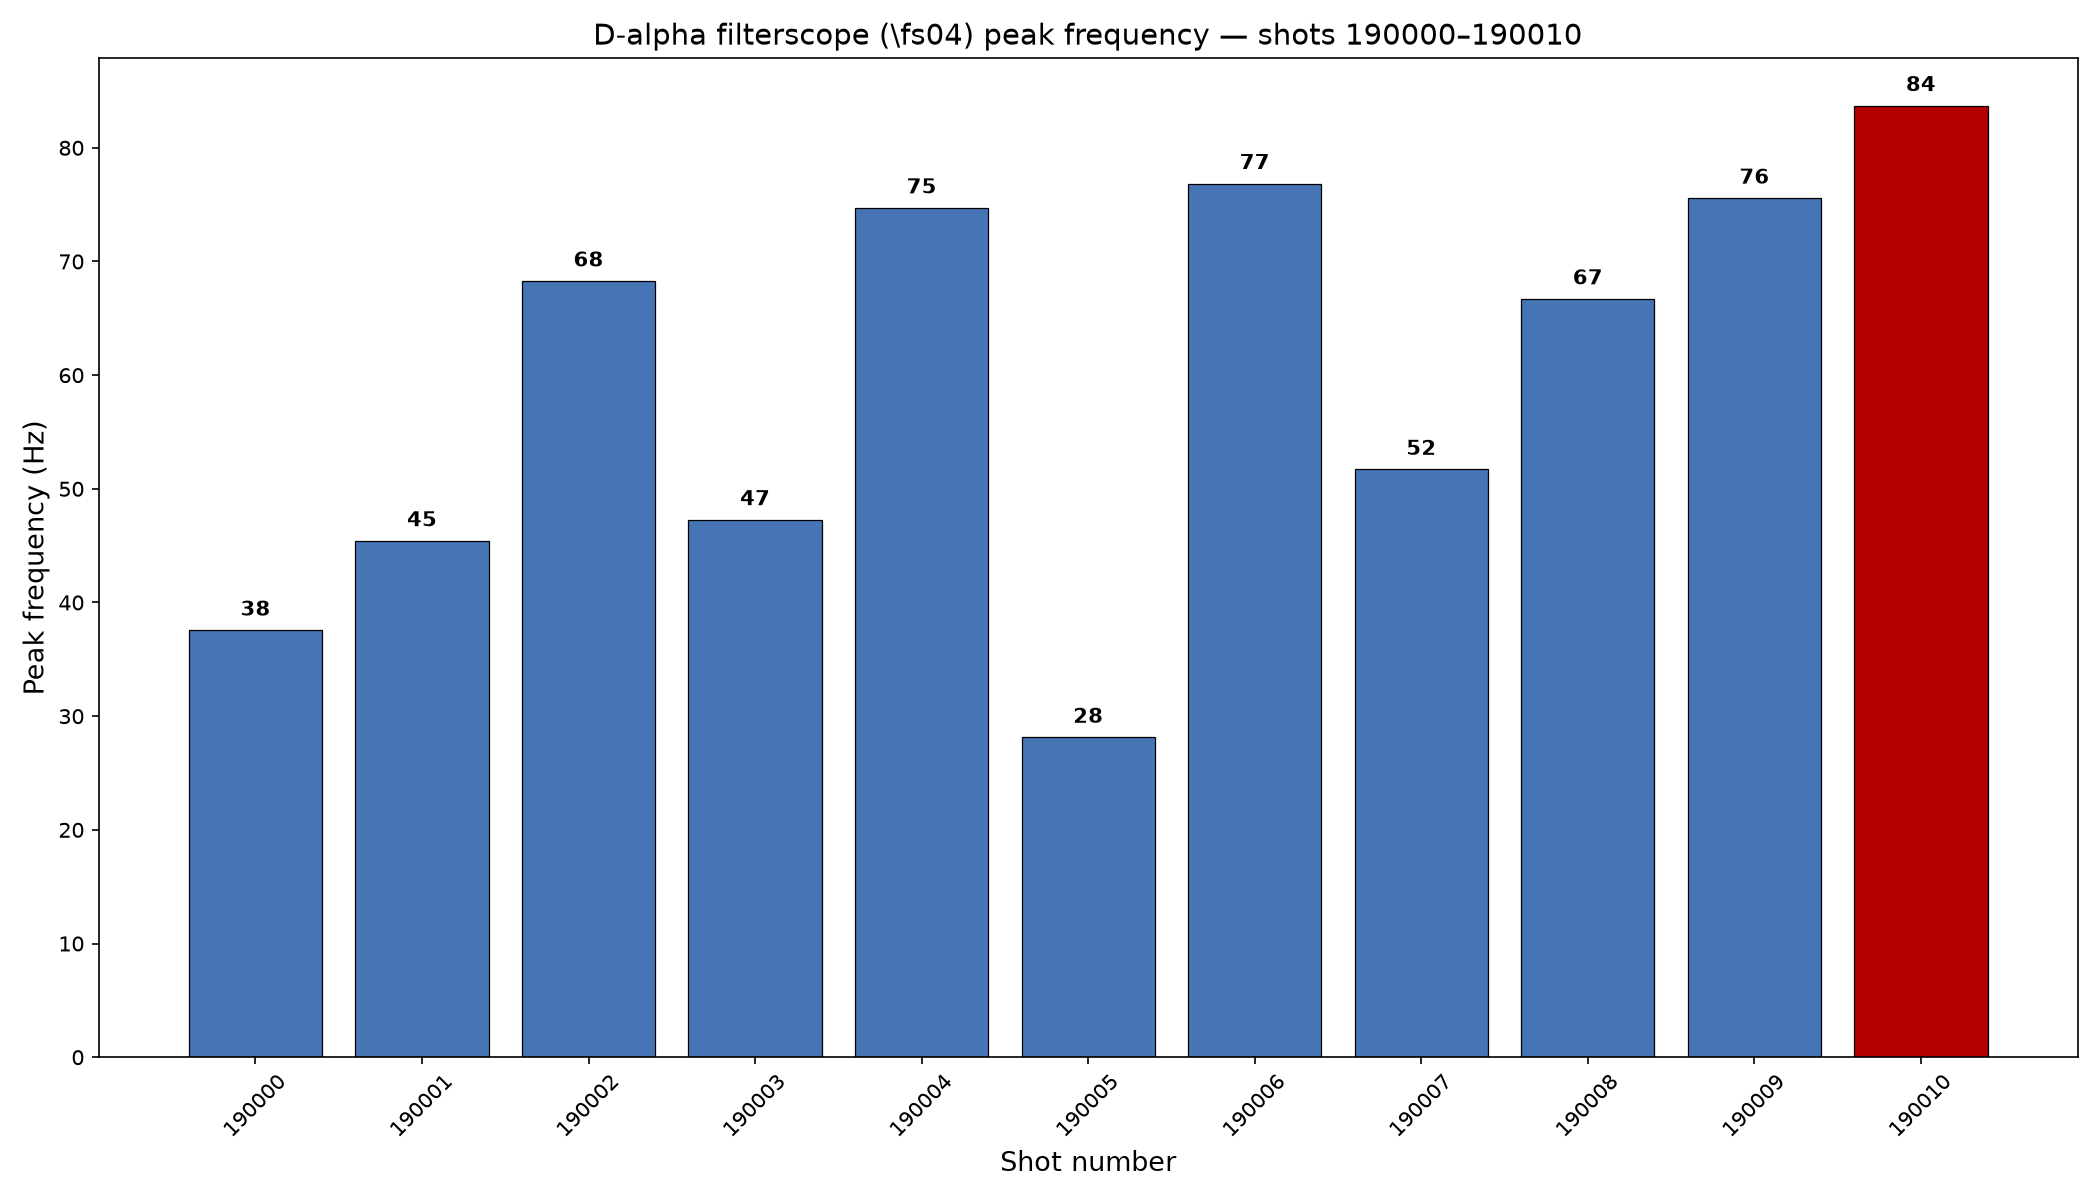

## Results — Peak frequency of `\fs04` for shots 190000–190010

For each shot I fetched the full `\fs04` trace (PMT42 photon flux, 350,000 samples at ~50 kHz over a 7.000 s window) and detected peaks with `scipy.signal.find_peaks` using a prominence threshold of 10% of the signal's dynamic range. **Peak frequency = #peaks ÷ time span.**

| Shot | Peaks detected | Time span (s) | Peak frequency (Hz) |
|------|---------------:|--------------:|--------------------:|
| 190000 | 263 | 7.000 | 37.6 |
| 190001 | 318 | 7.000 | 45.4 |
| 190002 | 478 | 7.000 | 68.3 |
| 190003 | 331 | 7.000 | 47.3 |
| 190004 | 523 | 7.000 | 74.7 |
| 190005 | 197 | 7.000 | 28.1 |
| 190006 | 538 | 7.000 | 76.9 |
| 190007 | 362 | 7.000 | 51.7 |
| 190008 | 467 | 7.000 | 66.7 |
| 190009 | 529 | 7.000 | 75.6 |
| **190010** | **586** | **7.000** | **83.7** |

**Shot 190010 has the highest peak frequency at 83.7 Hz** (586 peaks over the 7-second window), edging out shot 190006 (76.9 Hz) and shot 190009 (75.6 Hz). The lowest is shot 190005 at 28.1 Hz — roughly a 3× spread across the 11-shot span. These frequencies are consistent with the typical 10–200 Hz ELM repetition rate in H-mode plasmas.

**Fetch time** : all 11 shots were fetched in **24.6 seconds** using 8 parallel workers (~2.2 s/shot effective). A serial fetch exceeded the 120-second execution limit, so the multiprocessing approach was necessary.

### Peak-detection parameters

Peaks were identified with `find_peaks(data, prominence=0.10×range, distance=50)`. The 10% prominence threshold filters out low-amplitude noise fluctuations while keeping genuine ELM bursts; the `distance=50` (1 ms minimum spacing at 50 kHz) prevents double-counting shoulders on the same ELM event. Absolute peak counts are sensitive to this threshold — the *relative ranking* across shots is the robust output here.

In [7]:
%%ask
For DIII-D shots between 190000 and 190010, For each shot, calculate the peak
frequency by dividing the total number of peaks in \fs04 by the time span.
Find the shot with the highest peak frequency.